In [1]:
import os
import sys
from glob import glob
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to import logger, VR-wide constants and device paths
sys.path.append(os.path.join('.', ".."))
from baseVR.base_logger import CustomLogger as Logger
from baseVR.base_functionality import device_paths

nas_dir = device_paths()[0]


In [2]:
L = Logger()
L.init_logger(None, None, "DEBUG")

Logging at level DEBUG


In [4]:
nas_dir = device_paths()[0]
implant_name = "260611_MEA1K24_S1688pad14shankB5"
headstage_name = "MEA1K24"
subdir = f"devices/headstage_devices/{headstage_name}/recordings"

In [5]:
def load_impedance_data(rec_dir, nas_dir, subdir, implant_name):
    """Load and merge impedance data with implant mapping."""
    fullfname = os.path.join(nas_dir, "devices", "implant_devices", implant_name, "bonding", 
                            f"bonding_mapping_{implant_name}.csv")
    implant_mapping = pd.read_csv(fullfname)
    
    full_recdir = os.path.join(nas_dir, subdir, rec_dir)
    aggr_df = pd.read_csv(os.path.join(full_recdir, "processed", "all_impedance.csv"))
    aggr_df.rename(columns={"electrode": "mea1k_el"}, inplace=True)
    
    # Merge once with implant mapping
    aggr_df = pd.merge(aggr_df, implant_mapping[['mea1k_el', 'shank_id', 'mea1k_connectivity', 'pad_metal']], on='mea1k_el', how='left')
    aggr_df.rename(columns={'mea1k_el': 'electrode'}, inplace=True)
    
    return aggr_df, implant_mapping, full_recdir


In [17]:
rec_dir = f"2026-06-28_07.40_Bond4_ext200uA_check"
# rec_dir = f"2026-06-28_18.44_Bond4_ext200uA_singles"
# rec_dir = f"2026-06-28_19.44_Bond4_ext200uA_singles_votlagemode"
# rec_dir = f"2026-06-28_21.10_Bond4_ext200uA_singles_currentemode"

# rec_dir = f"2026-06-29_07.10_Bond4_ext200uA_singles_currentemode"
# rec_dir = f"2026-06-29_09.26_Bond4_ext200uA_singles_currentemode" # now using offset

rec_dir = f"2026-06-29_10.48_Bond4_ext200uA_singles"


_, implant_mapping, full_recdir = load_impedance_data(f"2026-06-24_20.35_bond4_Imp_GND_PT3_1.8mm_LC", nas_dir, subdir, implant_name)
extr_connectivity = pd.read_csv(os.path.join(nas_dir, subdir, rec_dir, "processed", "extr_connectivity.csv")).rename(columns={"el": 'mea1k_el'})

# join on mea1k_el to get shank_id and pad_metal
aggr_df = pd.merge(extr_connectivity, implant_mapping[['mea1k_el', 'shank_id', 'pad_metal', 'mea1k_connectivity']], on='mea1k_el', how='left')
display(aggr_df)

,config,mea1k_el,ampl,connectivity,ampl_mV,input_ampl_mV,shank_id,pad_metal,mea1k_connectivity
0,893,893,12.273867,0.613693,12.273867,20,2.0,1.0,0.202822
1,1668,1668,14.506716,0.725336,14.506716,20,5.0,2.0,0.206377
2,1692,1692,14.356003,0.717800,14.356003,20,6.0,2.0,0.201092
3,3285,3285,1.581293,0.079065,1.581293,20,7.0,2.0,0.891773
4,3427,3427,12.454591,0.622730,12.454591,20,5.0,2.0,0.255375
...,...,...,...,...,...,...,...,...,...
3095,5726,25726,2.980844,0.149042,2.980844,20,10.0,1.0,0.697969
3096,5728,25728,2.870766,0.143538,2.870766,20,10.0,1.0,0.655457
3097,5730,25730,3.266630,0.163332,3.266630,20,10.0,1.0,0.795686
3098,5731,25731,2.579133,0.128957,2.579133,20,10.0,1.0,0.786483


Text(0, 0.5, 'Sensing 0.2uA current')

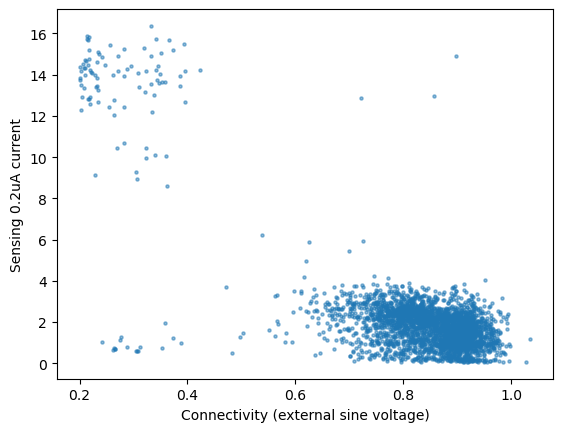

In [18]:
plt.close('all')
# plt.scatter(aggr_df['mea1k_connectivity'], (aggr_df['ampl_mV']*1000) /0.2, s=5, alpha=0.5)
plt.scatter(aggr_df['mea1k_connectivity'], (aggr_df['ampl_mV']), s=5, alpha=0.5)
# add labels
plt.xlabel("Connectivity (external sine voltage)")
plt.ylabel("Sensing 0.2uA current")

In [19]:
aggr_df
x, y = aggr_df['mea1k_el'].values %220, aggr_df['mea1k_el'].values // 220

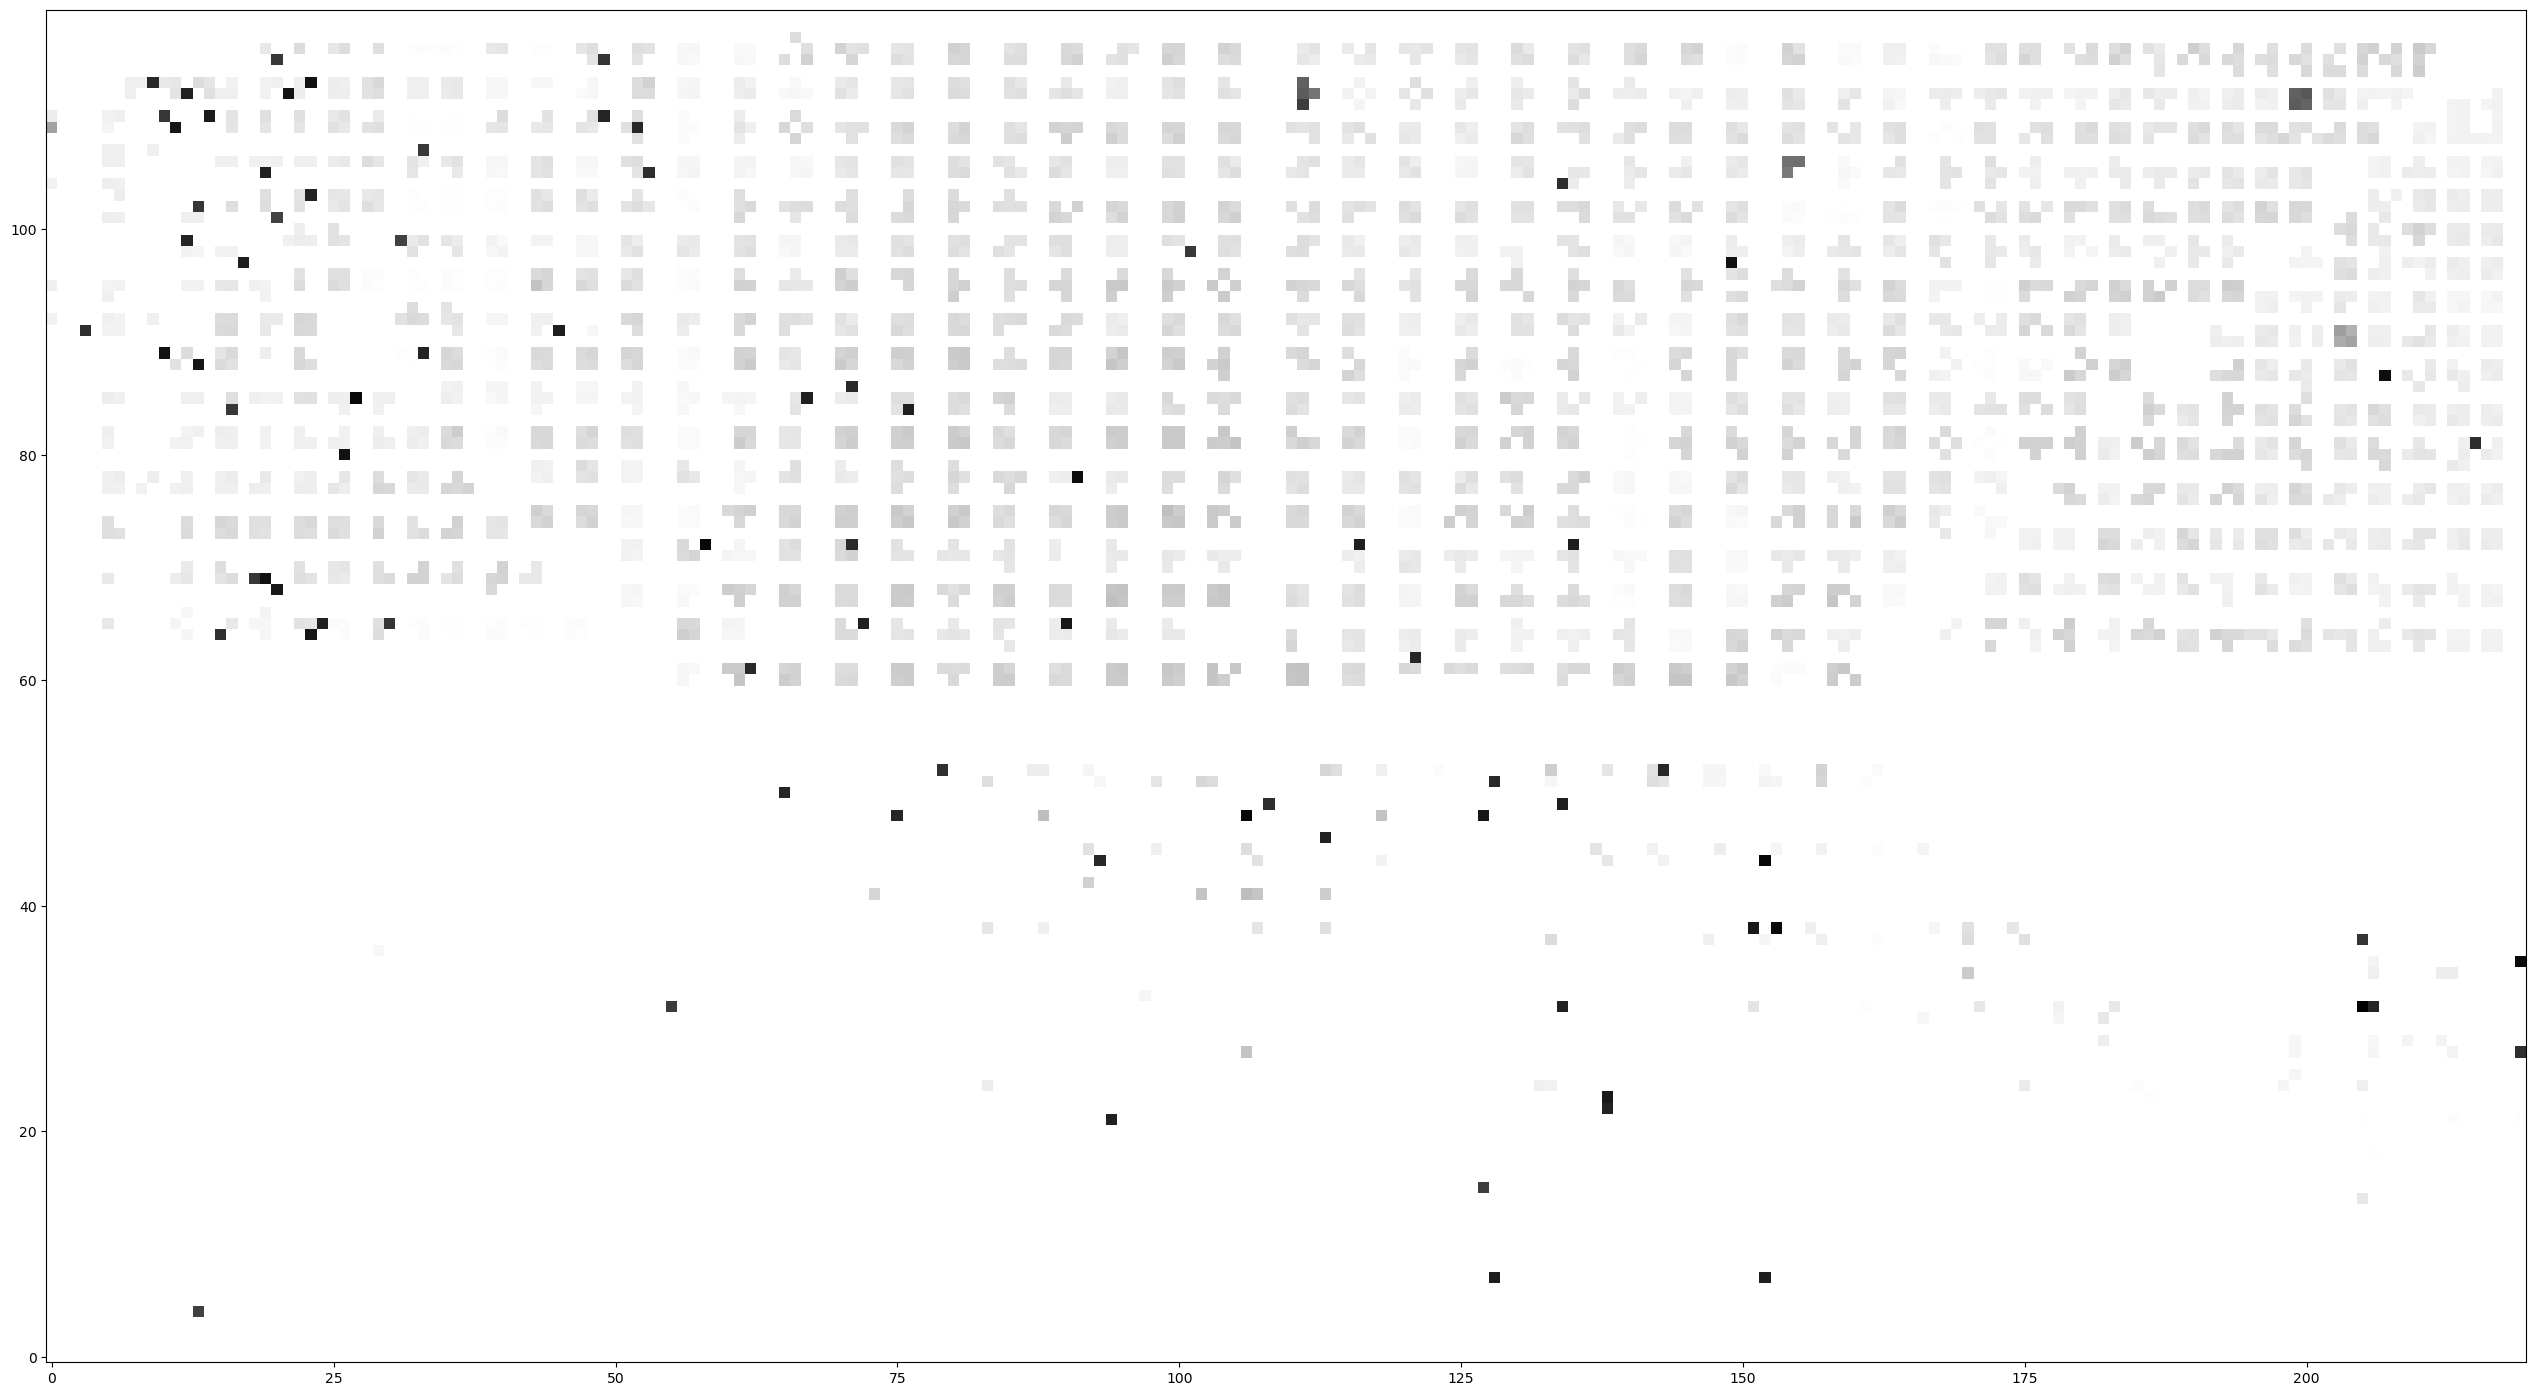

In [20]:
grid = np.zeros((120, 220))
grid[y, x] = aggr_df['ampl_mV'].values
plt.figure(figsize=(32, 26))
plt.imshow(grid, cmap='gray_r', origin='lower')

In [21]:
nas_dir = device_paths()[0]
implant_name = "260602_MEA1K23_S844pad8shankB5"
headstage_name = "MEA1K23"
subdir = f"devices/headstage_devices/{headstage_name}/recordings"

In [34]:
rec_name1 = f"2026-06-30_14.42_8Sh4SilverPaint_Ext0.2uA_PT1_1.7mm_+MANYd_S1-8no7,8/"
rec_name2 = f"2026-06-30_14.44_8Sh4SilverPaint_Ext10mV_PT1_1.7mm_+MANYd_S1-8no7,8/"
# singles
rec_name3 = f"2026-07-01_15.46_8Sh4SilverPaint_Ext0.2uA_Singles_PT1_1.7mm_+MANYd_S1-8no7,8"
#  /mnt/SpatialSequenceLearning/devices/headstage_devices/MEA1K23/recordings/2026-06-30_10.58_8Sh4SilverPaint_ImpLate_7removed_LC/processed/all_impedance.csv 
rec_name4 = f"2026-06-30_10.58_8Sh4SilverPaint_ImpLate_7removed_LC"

par_current = pd.read_csv(os.path.join(nas_dir, subdir, rec_name1, "processed", "extr_connectivity.csv")).rename(columns={"el": 'mea1k_el'}).set_index('mea1k_el')
par_voltage = pd.read_csv(os.path.join(nas_dir, subdir, rec_name2, "processed", "extr_connectivity.csv")).rename(columns={"el": 'mea1k_el'}).set_index('mea1k_el')
singles_current = pd.read_csv(os.path.join(nas_dir, subdir, rec_name3, "processed", "extr_connectivity.csv")).rename(columns={"el": 'mea1k_el'}).set_index('mea1k_el')
impedance = pd.read_csv(os.path.join(nas_dir, subdir, rec_name4, "processed", "all_impedance.csv")).set_index('electrode')

electrodes = singles_current.index

impedance

,Unnamed: 0,stim_unit,stim_mode,LSB_nA,dac_id,stim_sequence_DAC_amplitude,stim_sequence_frequency_Hz,stim_sequence_ncycles,connectivity,amplitude_uV,current_uA,external_current_uA,impedance_Ohm,external_impedance_Ohm,phase_shift_deg
electrode,,,,,,,,,,,,,,,
9072,0,0,large_current,50.569918,0,3,1000,400,0.754100,9695.561809,0.151710,NaN,6.390863e+04,NaN,81.436044
9952,0,0,large_current,50.569918,0,3,1000,400,0.747002,21074.546453,0.151710,NaN,1.389136e+05,NaN,76.301413
13691,0,0,large_current,50.569918,0,3,1000,400,0.750330,9870.791226,0.151710,NaN,6.506366e+04,NaN,70.814898
9295,0,0,large_current,50.569918,0,3,1000,400,0.745293,6381.102379,0.151710,NaN,4.206125e+04,NaN,74.791564
14356,0,0,large_current,50.569918,0,3,1000,400,0.747686,15977.936957,0.151710,NaN,1.053191e+05,NaN,69.855119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13789,0,31,large_current,45.423650,0,3,1000,400,0.654293,1066.091026,0.136271,NaN,7.823318e+03,NaN,36.502150
15995,0,31,large_current,45.423650,0,3,1000,400,0.662813,3508.785613,0.136271,NaN,2.574860e+04,NaN,70.430191
15554,0,31,large_current,45.423650,0,3,1000,400,0.675545,3485.070439,0.136271,NaN,2.557457e+04,NaN,68.747897


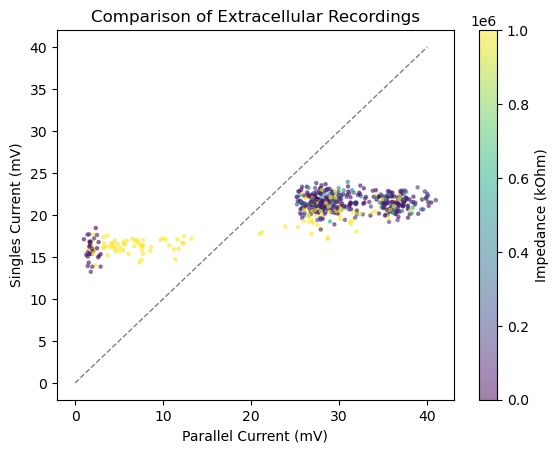

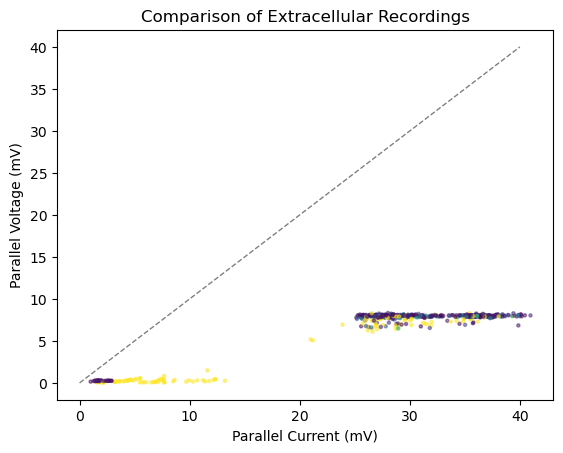

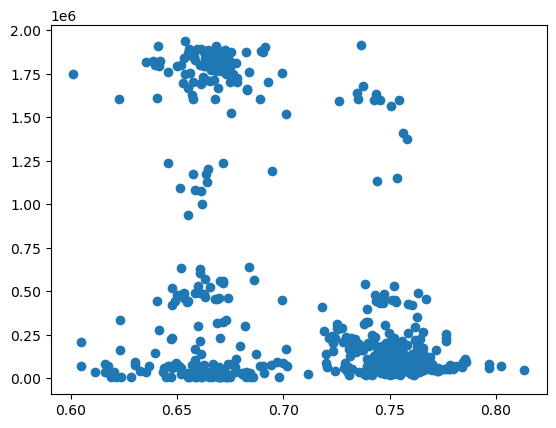

In [50]:
# compare
sc = plt.scatter(par_current.loc[electrodes, 'ampl_mV'], singles_current.loc[electrodes, 'ampl_mV'], 
            s=5, alpha=0.5, c=impedance.reindex(electrodes)['impedance_Ohm'], cmap='viridis', vmin=0, vmax=1_000_000)
plt.xlabel('Parallel Current (mV)')
plt.ylabel('Singles Current (mV)')
plt.title('Comparison of Extracellular Recordings')
# identy line
plt.plot([0, 40], [0, 40],  linestyle='--', linewidth=1, color='gray')
# add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Impedance (kOhm)')
plt.show()

# compare
plt.scatter(par_current.loc[electrodes, 'ampl_mV'], par_voltage.loc[electrodes, 'ampl_mV'], 
            s=5, alpha=0.5, c=impedance.reindex(electrodes)['impedance_Ohm'], cmap='viridis', vmin=0, vmax=1_000_000)
plt.xlabel('Parallel Current (mV)')
plt.ylabel('Parallel Voltage (mV)')
plt.plot([0, 40], [0, 40],  linestyle='--', linewidth=1, color='gray')
plt.title('Comparison of Extracellular Recordings')
plt.show()

plt.scatter(impedance.reindex(electrodes)['connectivity'],  impedance.reindex(electrodes)['impedance_Ohm'], )

